In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [2]:
df = pd.read_csv("Salary_Data.csv")

In [3]:
print(df.shape)

(375, 6)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    str    
 2   Education Level      373 non-null    str    
 3   Job Title            373 non-null    str    
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), str(3)
memory usage: 30.8 KB


In [5]:
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64


In [6]:
df = df.dropna()
df.isnull().sum()
print("Shape after dropping null values: ", df.shape)

Shape after dropping null values:  (373, 6)


In [7]:
print("Duplicated Values: ", df.duplicated().sum())

Duplicated Values:  49


In [8]:
df = df.drop_duplicates()
print(df.duplicated().sum())
print("Shape after dropping duplicated values: ", df.shape)

0
Shape after dropping duplicated values:  (324, 6)


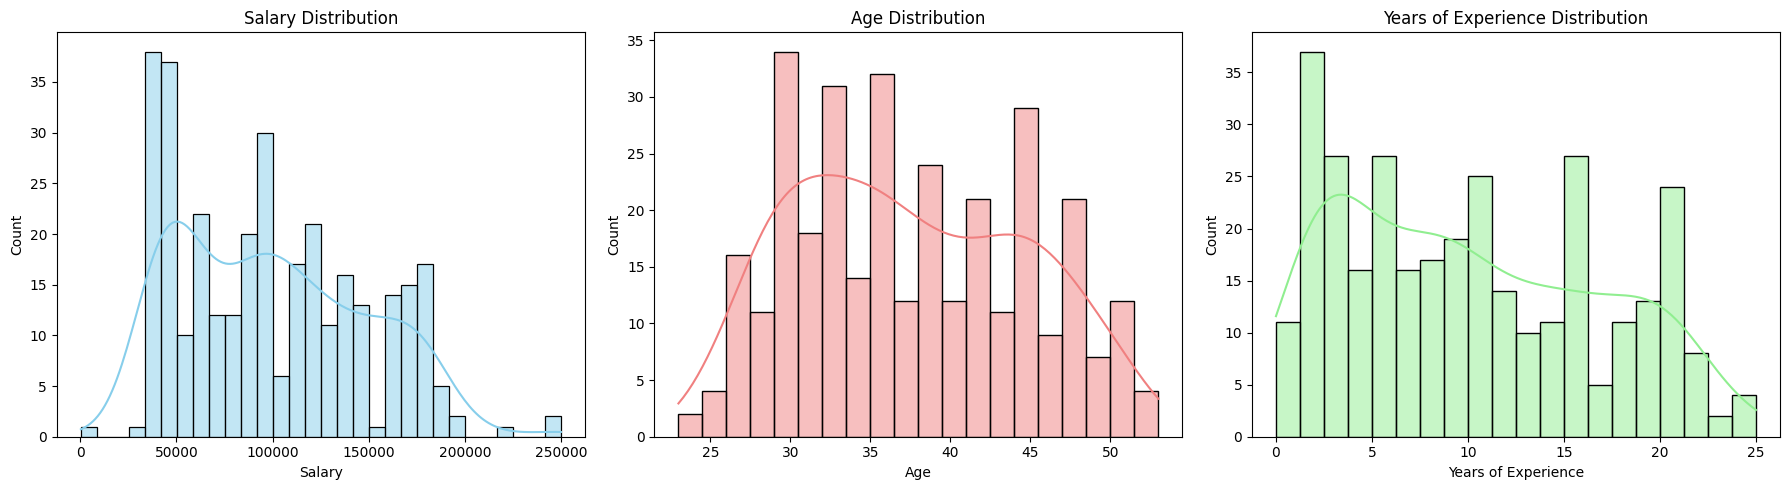

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Salary
sns.histplot(df["Salary"], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Salary Distribution")

# Age
sns.histplot(df["Age"], bins=20, kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title("Age Distribution")

# Years of Experience
sns.histplot(df["Years of Experience"], bins=20, kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title("Years of Experience Distribution")

plt.tight_layout()
plt.show()

In [10]:
#Encode Categorical Features
#label encoding, first sort the values alphabetically then assign a number to each value

df["Gender"] = LabelEncoder().fit_transform(df["Gender"]) # M=1, F=0
df["Education Level"] = LabelEncoder().fit_transform(df["Education Level"]) 
df["Job Title"] = LabelEncoder().fit_transform(df["Job Title"])

df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,0,159,5.0,90000.0
1,28.0,0,1,17,3.0,65000.0
2,45.0,1,2,130,15.0,150000.0
3,36.0,0,0,101,7.0,60000.0
4,52.0,1,1,22,20.0,200000.0


In [11]:
#Experience Squared
df["Experience_Squared"] = df["Years of Experience"] ** 2

#Age to Experience Ratio
df["Age_Experience_Ratio"] = df["Age"] / (df["Years of Experience"] + 1)

#Age × Experience
df["Age_Experience"] = df["Age"] * df["Years of Experience"]

print(df.head())

    Age  Gender  Education Level  Job Title  Years of Experience    Salary  \
0  32.0       1                0        159                  5.0   90000.0   
1  28.0       0                1         17                  3.0   65000.0   
2  45.0       1                2        130                 15.0  150000.0   
3  36.0       0                0        101                  7.0   60000.0   
4  52.0       1                1         22                 20.0  200000.0   

   Experience_Squared  Age_Experience_Ratio  Age_Experience  
0                25.0              5.333333           160.0  
1                 9.0              7.000000            84.0  
2               225.0              2.812500           675.0  
3                49.0              4.500000           252.0  
4               400.0              2.476190          1040.0  


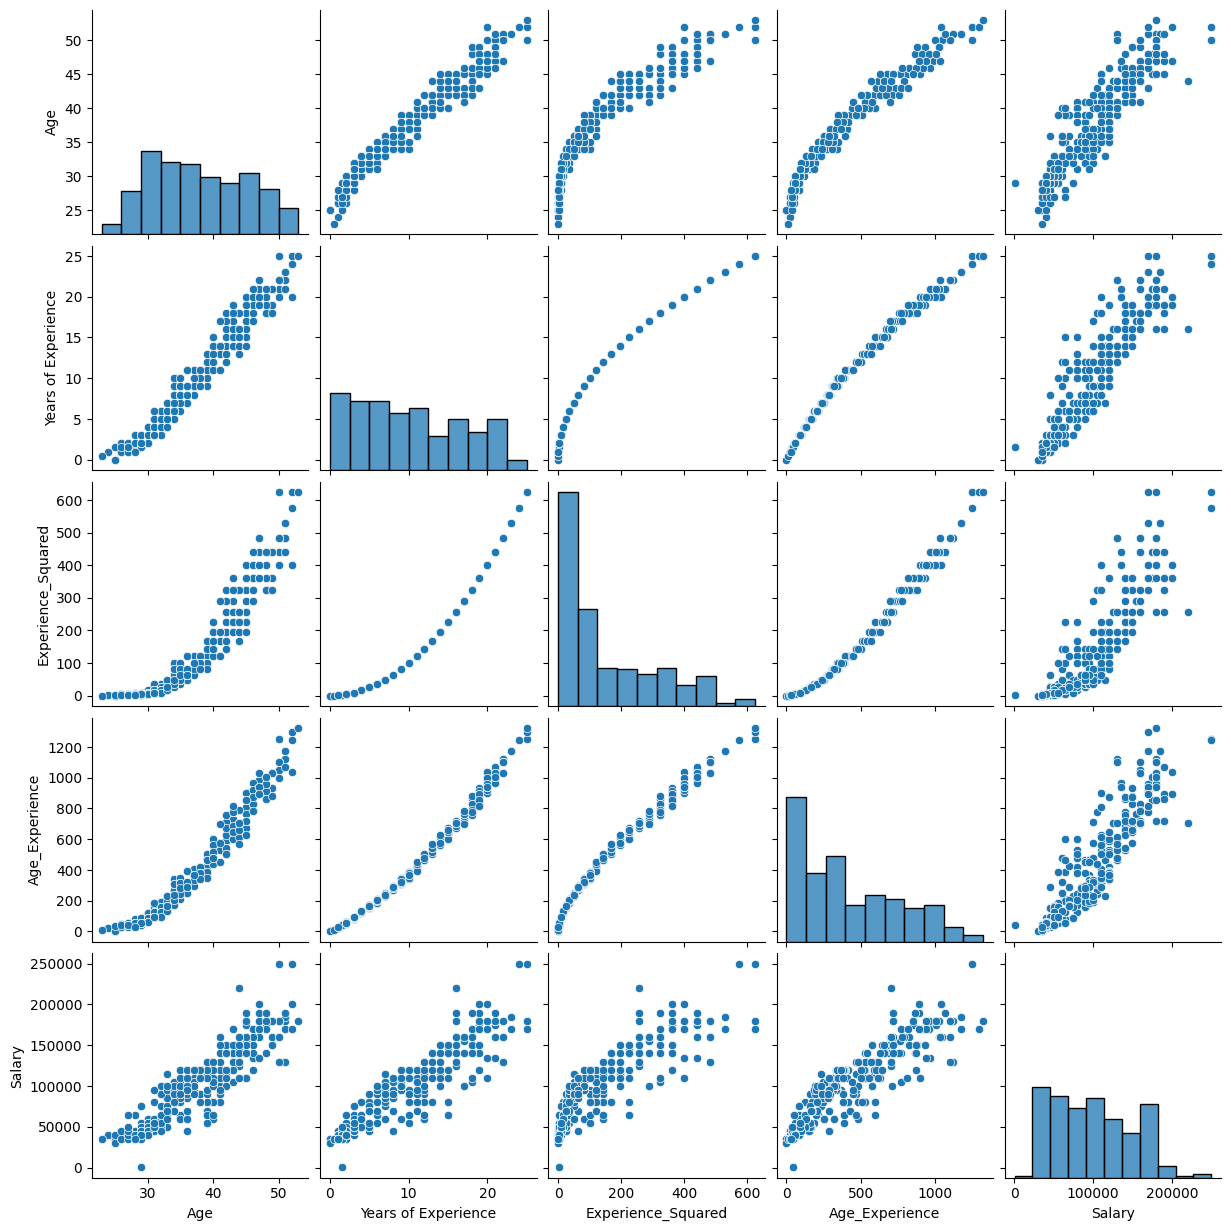

In [12]:
sns.pairplot(
    df[
        ["Age",
         "Years of Experience",
         "Experience_Squared",
         "Age_Experience",
         "Salary"]
    ]
)

plt.show()

In [13]:
X = df.drop("Salary", axis=1)
y = df["Salary"]

print("Features:", X.columns.tolist())

Features: ['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience', 'Experience_Squared', 'Age_Experience_Ratio', 'Age_Experience']


In [14]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

Training Features: (259, 8)
Testing Features : (65, 8)


In [15]:
# Train Model
single_model = LinearRegression()
single_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_single = single_model.predict(X_test_scaled)

# Evaluation
rmse_single = np.sqrt(mean_squared_error(y_test, y_pred_single))
r2_single = r2_score(y_test, y_pred_single)

print("===== Single Feature Model =====")
print("RMSE :", rmse_single)
print("R² Score :", r2_single)

===== Single Feature Model =====
RMSE : 13944.541300550134
R² Score : 0.8971046822158834


In [16]:
# Train Model
multiple_model = LinearRegression()
multiple_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_multi = multiple_model.predict(X_test_scaled)

# Evaluation
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))
r2_multi = r2_score(y_test, y_pred_multi)

print("===== Multiple Feature Model =====")
print("RMSE :", rmse_multi)
print("R² Score :", r2_multi)

===== Multiple Feature Model =====
RMSE : 13944.541300550134
R² Score : 0.8971046822158834


            Model         RMSE  R² Score
   Single Feature 13944.541301  0.897105
Multiple Features 13944.541301  0.897105


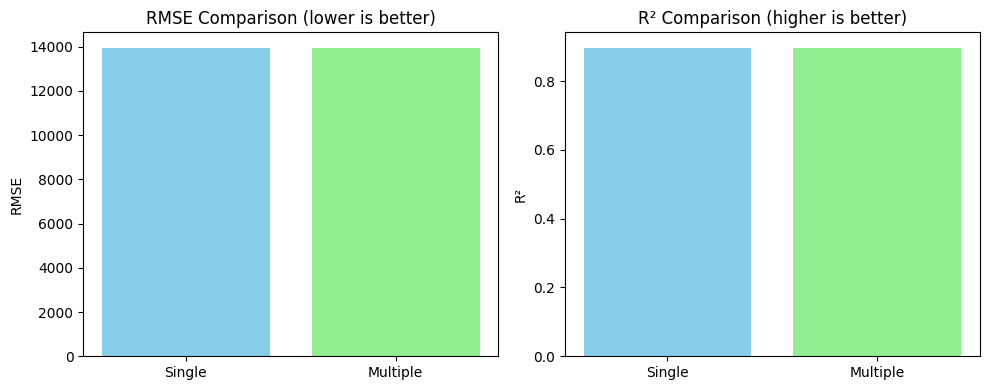

In [17]:
comparison = pd.DataFrame({
    "Model": ["Single Feature", "Multiple Features"],
    "RMSE": [rmse_single, rmse_multi],
    "R² Score": [r2_single, r2_multi]
})
print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Single', 'Multiple'], [rmse_single, rmse_multi], color=['skyblue', 'lightgreen'])
axes[0].set_title('RMSE Comparison (lower is better)')
axes[0].set_ylabel('RMSE')

axes[1].bar(['Single', 'Multiple'], [r2_single, r2_multi], color=['skyblue', 'lightgreen'])
axes[1].set_title('R² Comparison (higher is better)')
axes[1].set_ylabel('R²')

plt.tight_layout()
plt.show()

In [20]:
#select best model
if r2_multi > r2_single:
    best_model = multiple_model
else:
    best_model = single_model

print("Best Model:", "Multiple Features" if best_model == multiple_model else "Single Feature")    

Best Model: Single Feature


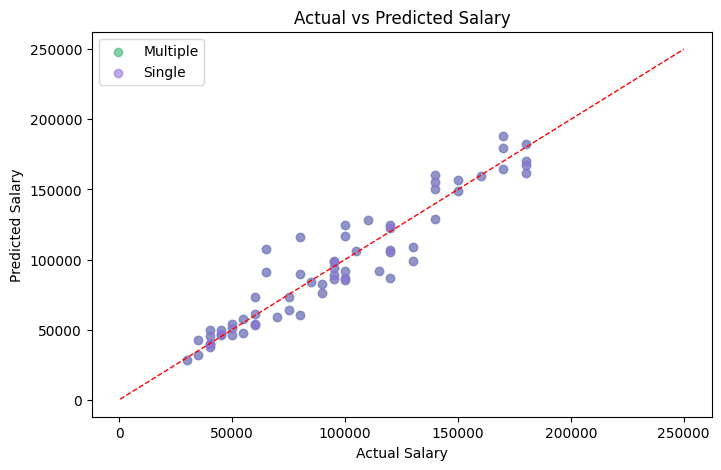

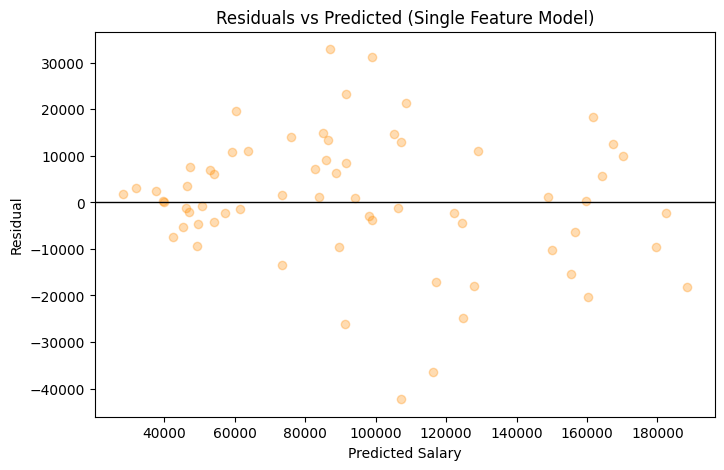

In [21]:
#Actual vs Predicted + Residual plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_multi, alpha=0.6, color='mediumseagreen', label='Multiple')
plt.scatter(y_test, y_pred_single, alpha=0.6, color='mediumpurple', label='Single')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=1)
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs Predicted Salary')
plt.legend()
plt.show()

residuals = y_test - y_pred_single

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_single, residuals, alpha=0.3, color='darkorange')
plt.axhline(0, color='black', linewidth=1)
plt.xlabel('Predicted Salary')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted (Single Feature Model)')
plt.show()

In [22]:
#save best model
joblib.dump(best_model,"salary_model.pkl")
joblib.dump(scaler,"salary_scaler.pkl")

print("Model and scaler saved")

Model and scaler saved


In [ ]:
#test the saved model